<a href="https://colab.research.google.com/github/abhinav343/Machine-Learning/blob/main/taxi_fare_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/taxi-fare-guru-total-amount-prediction-challenge/sample.csv.csv
/kaggle/input/taxi-fare-guru-total-amount-prediction-challenge/train.csv
/kaggle/input/taxi-fare-guru-total-amount-prediction-challenge/test.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sample = pd.read_csv("/kaggle/input/taxi-fare-guru-total-amount-prediction-challenge/sample.csv.csv")
sample

,ID,total_amount
0,1,24.456348
1,2,24.374058
2,3,19.878154
3,4,25.015569
4,5,22.252489
...,...,...
995,996,24.438531
996,997,26.773706
997,998,22.192718
998,999,142.698686


In [ ]:
data = pd.read_csv('/kaggle/input/taxi-fare-guru-total-amount-prediction-challenge/train.csv')
test=pd.read_csv("/kaggle/input/taxi-fare-guru-total-amount-prediction-challenge/test.csv")

In [ ]:
print(data.head())
print(data.info())

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2023-06-28 17:20:21   2023-06-28 16:34:45              1.0   
1         0  2023-06-29 23:05:01   2023-06-29 22:01:35              1.0   
2         1  2023-06-30 10:19:31   2023-06-30 11:13:10              1.0   
3         0  2023-06-29 13:23:09   2023-06-29 14:20:01              1.0   
4         1  2023-06-29 22:03:32   2023-06-29 22:22:22              3.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           2.14         1.0                  N           120             9   
1           2.70         1.0                  N            15           215   
2           1.15         1.0                  N           167           223   
3           0.40         1.0                  N           128           239   
4           1.10         1.0                  N           203            52   

  payment_type  extra  tip_amount  tolls_amount  improvement_surcharge  \


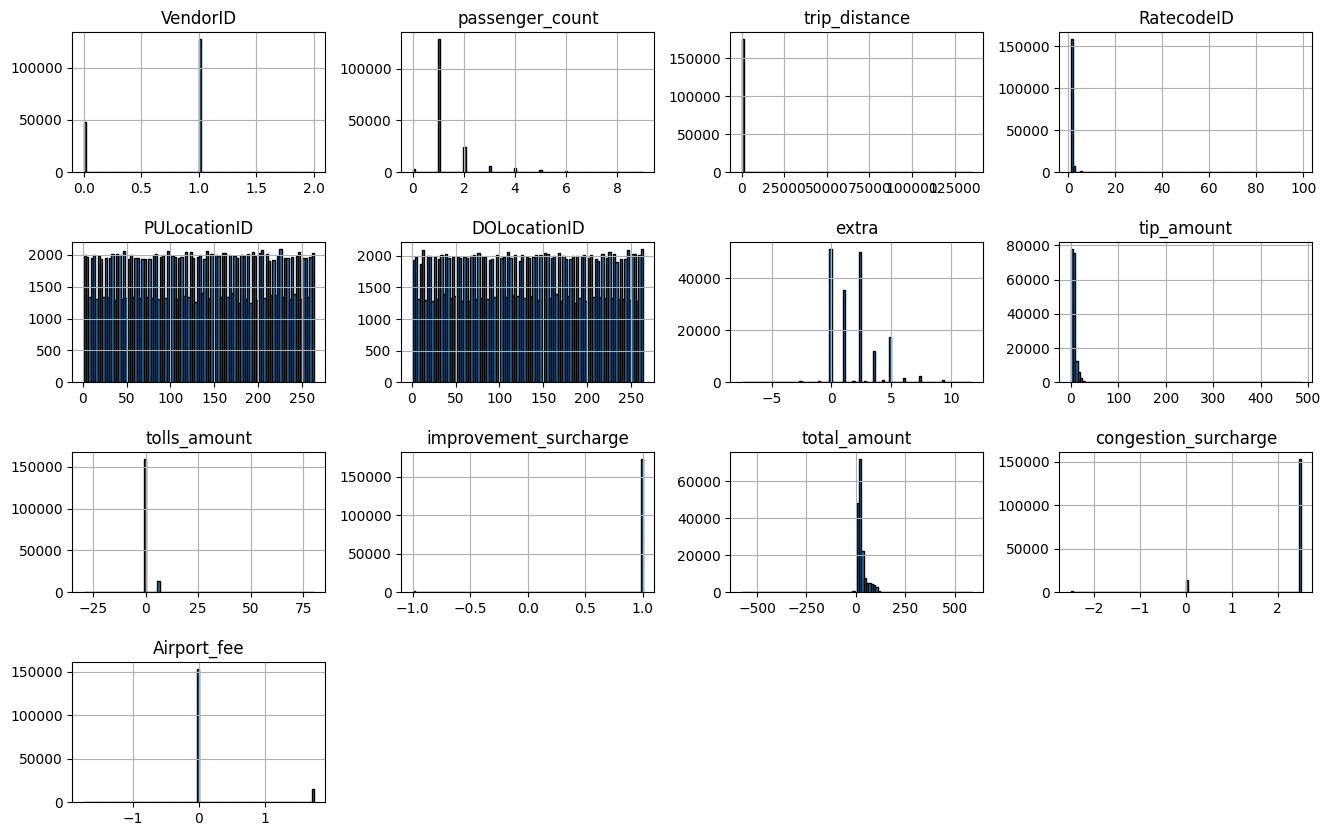

In [ ]:
data.hist(bins = 100, edgecolor = 'black', figsize=(16,10))
plt.subplots_adjust(hspace = 0.5,wspace = 0.3)
plt.show()

In [ ]:
data.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,175000.000000,168923.000000,175000.000000,168923.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,168923.000000,168923.000000
mean,0.728377,1.357678,5.145930,1.518307,132.710349,132.701429,1.932143,6.127497,0.646816,0.979689,29.633901,2.246971,0.158825
std,0.445606,0.891283,394.971052,6.514678,76.148799,76.192493,1.948497,4.610834,2.328274,0.198775,25.425206,0.819216,0.511968
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,-7.500000,0.000079,-29.300000,-1.000000,-576.750000,-2.500000,-1.750000
25%,0.000000,1.000000,1.080000,1.000000,67.000000,67.000000,0.000000,3.473321,0.000000,1.000000,16.300000,2.500000,0.000000
50%,1.000000,1.000000,1.840000,1.000000,133.000000,133.000000,1.000000,5.286217,0.000000,1.000000,21.450000,2.500000,0.000000
75%,1.000000,1.000000,3.610000,1.000000,199.000000,199.000000,2.500000,7.502746,0.000000,1.000000,31.800000,2.500000,0.000000
max,2.000000,9.000000,135182.060000,99.000000,264.000000,264.000000,11.750000,484.876151,80.000000,1.000000,587.250000,2.500000,1.750000


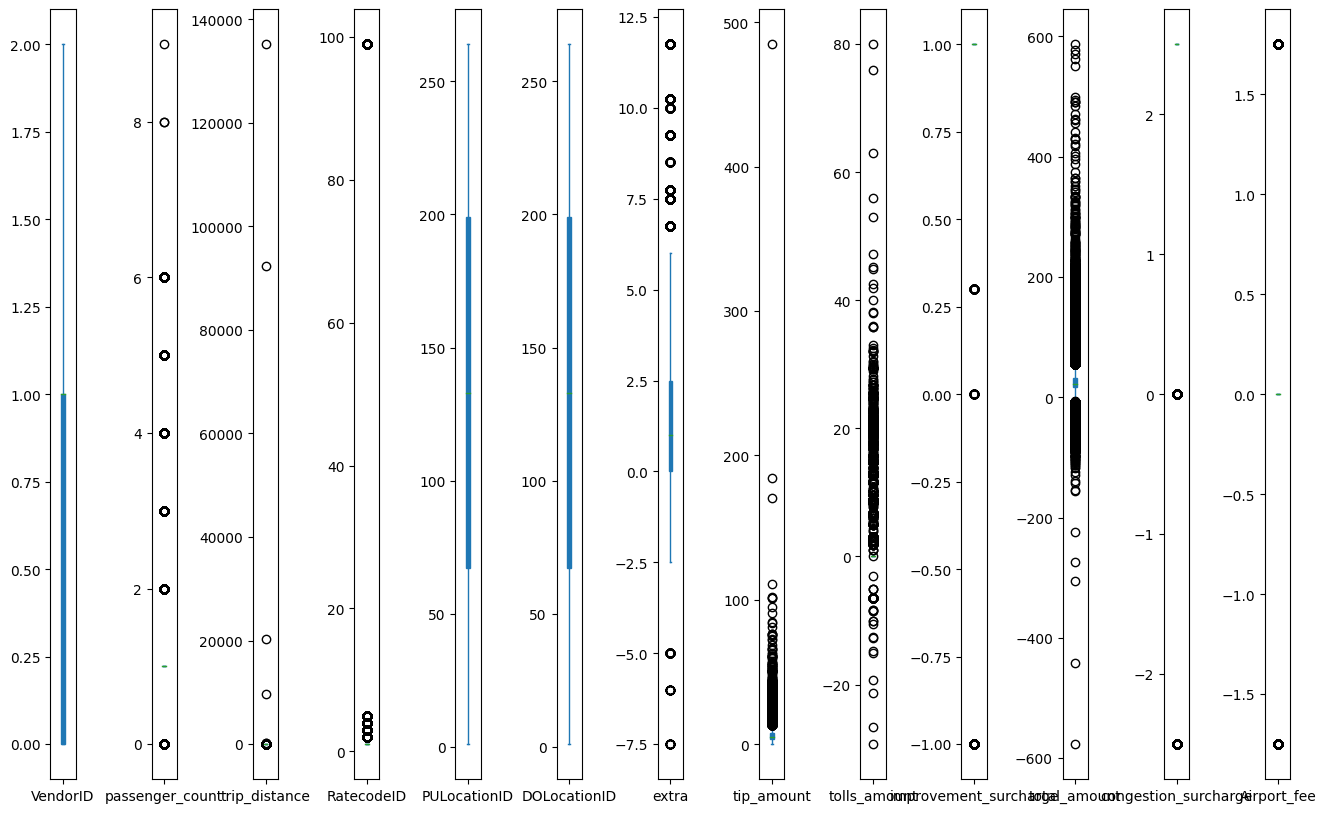

In [ ]:
data.plot(kind='box',sharey = False, subplots=True, figsize=(16,10),patch_artist=True,return_type='both')
plt.subplots_adjust(wspace = 3)
plt.show()

In [ ]:
data.loc[data['trip_distance'] > 500, 'trip_distance'] = 5.145930
data.loc[data['tip_amount'] > 200, 'tip_amount'] = 6.127497

In [ ]:
data['extra'] = data['extra'].abs()
data['tolls_amount'] = data['tolls_amount'].abs()
data['improvement_surcharge'] = data['improvement_surcharge'].abs()
data['total_amount'] = data['total_amount'].abs()
data['congestion_surcharge'] = data['congestion_surcharge'].abs()
data['Airport_fee'] = data['Airport_fee'].abs()
data.describe()

,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,175000.000000,168923.000000,175000.000000,168923.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,175000.000000,168923.000000,168923.000000
mean,0.728377,1.357678,3.674836,1.518307,132.710349,132.701429,1.959172,6.124762,0.657496,0.999403,30.185621,2.287995,0.164192
std,0.445606,0.891283,4.879805,6.514678,76.148799,76.192493,1.921318,4.466549,2.325280,0.022244,24.767667,0.696469,0.510273
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000079,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.080000,1.000000,67.000000,67.000000,0.000000,3.473321,0.000000,1.000000,16.320000,2.500000,0.000000
50%,1.000000,1.000000,1.840000,1.000000,133.000000,133.000000,1.750000,5.286217,0.000000,1.000000,21.480000,2.500000,0.000000
75%,1.000000,1.000000,3.610000,1.000000,199.000000,199.000000,2.500000,7.502695,0.000000,1.000000,31.920000,2.500000,0.000000
max,2.000000,9.000000,143.350000,99.000000,264.000000,264.000000,11.750000,184.313458,80.000000,1.000000,587.250000,2.500000,1.750000


In [ ]:
data['travel_time'] = (((pd.to_datetime(data['tpep_dropoff_datetime']))- (pd.to_datetime(data['tpep_pickup_datetime']))).dt.total_seconds()/60)
data['travel_time'] = data['travel_time'].abs()
data = data.drop(columns = ['tpep_dropoff_datetime','tpep_pickup_datetime','RatecodeID','payment_type','store_and_fwd_flag'])

In [ ]:
print(data.describe())
print(data.info())

            VendorID  passenger_count  trip_distance   PULocationID  \
count  175000.000000    168923.000000  175000.000000  175000.000000   
mean        0.728377         1.357678       3.674836     132.710349   
std         0.445606         0.891283       4.879805      76.148799   
min         0.000000         0.000000       0.000000       1.000000   
25%         0.000000         1.000000       1.080000      67.000000   
50%         1.000000         1.000000       1.840000     133.000000   
75%         1.000000         1.000000       3.610000     199.000000   
max         2.000000         9.000000     143.350000     264.000000   

        DOLocationID          extra     tip_amount   tolls_amount  \
count  175000.000000  175000.000000  175000.000000  175000.000000   
mean      132.701429       1.959172       6.124762       0.657496   
std        76.192493       1.921318       4.466549       2.325280   
min         1.000000       0.000000       0.000079       0.000000   
25%        67.0

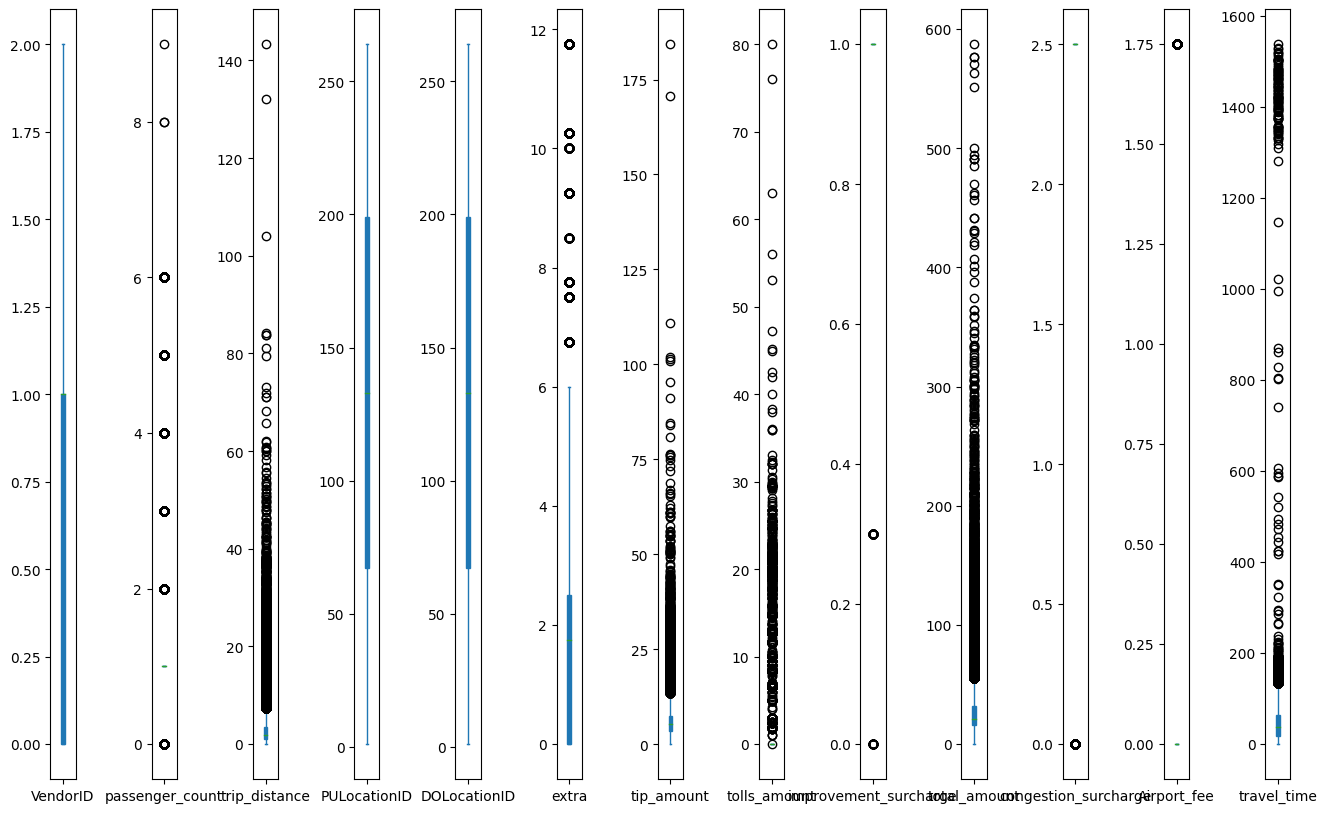

In [ ]:
data.plot(kind='box',sharey = False, subplots=True, figsize=(16,10),patch_artist=True,return_type='both')
plt.subplots_adjust(wspace = 3)
plt.show()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175000 entries, 0 to 174999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VendorID               175000 non-null  int64  
 1   passenger_count        168923 non-null  float64
 2   trip_distance          175000 non-null  float64
 3   PULocationID           175000 non-null  int64  
 4   DOLocationID           175000 non-null  int64  
 5   extra                  175000 non-null  float64
 6   tip_amount             175000 non-null  float64
 7   tolls_amount           175000 non-null  float64
 8   improvement_surcharge  175000 non-null  float64
 9   total_amount           175000 non-null  float64
 10  congestion_surcharge   168923 non-null  float64
 11  Airport_fee            168923 non-null  float64
 12  travel_time            175000 non-null  float64
dtypes: float64(10), int64(3)
memory usage: 17.4 MB


In [ ]:
X=data.drop('total_amount',axis=1)
y=data['total_amount']

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X=scaler.fit_transform(X)

In [ ]:
X_train,X_val,y_train,y_val = train_test_split(X,y,test_size = 0.2, random_state=42 )

In [ ]:
#X_train.plot(kind='box',sharey = False, subplots=True, figsize=(16,10),patch_artist=True,return_type='both')
#plt.subplots_adjust(wspace = 3)
#plt.show()

In [ ]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='mean')
X_train=si.fit_transform(X_train)
X_val=si.fit_transform(X_val)

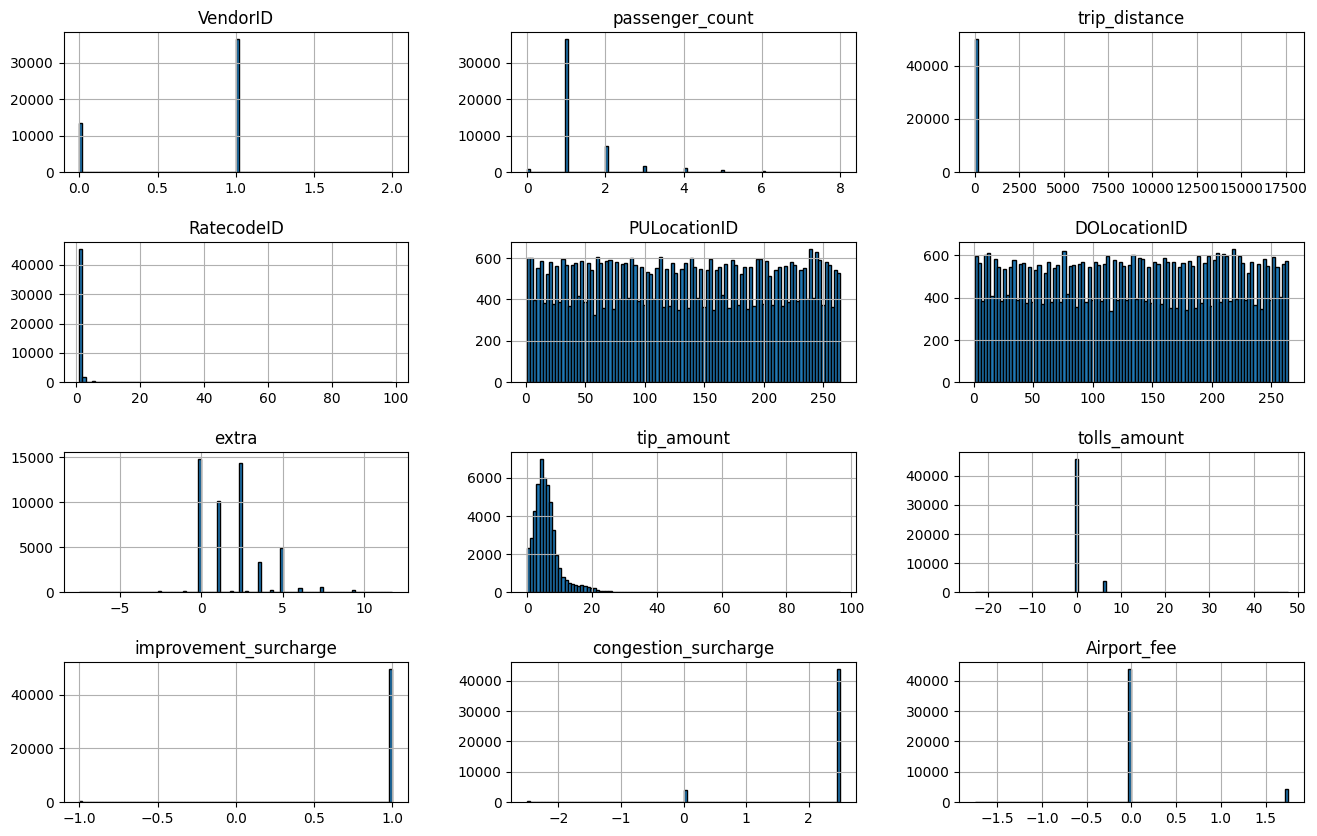

In [ ]:
test.hist(bins = 100, edgecolor = 'black', figsize=(16,10))
plt.subplots_adjust(hspace = 0.5,wspace = 0.3)
plt.show()

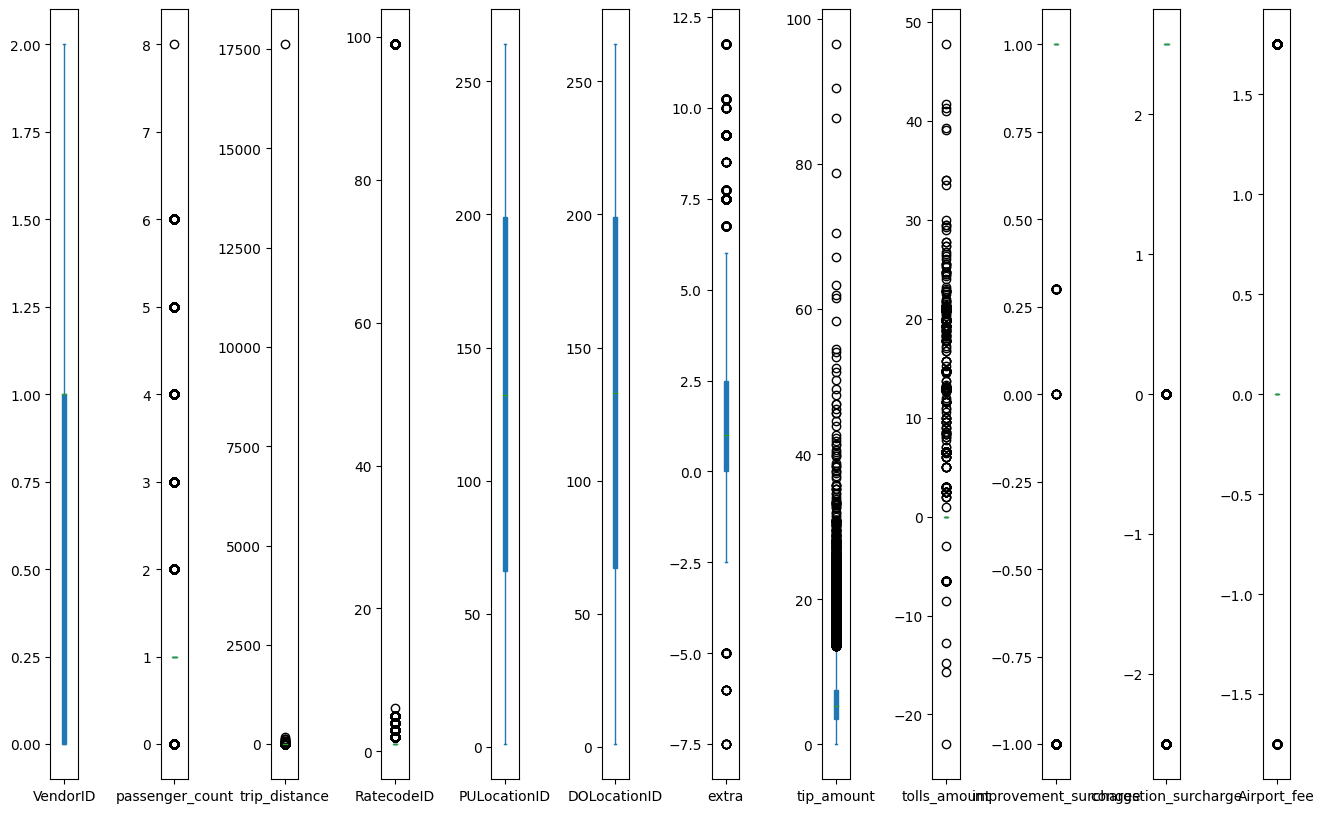

In [ ]:
test.plot(kind='box',sharey = False, subplots=True, figsize=(16,10),patch_artist=True,return_type='both')
plt.subplots_adjust(wspace = 3)
plt.show()

In [ ]:
test['travel_time'] = (((pd.to_datetime(test['tpep_dropoff_datetime']))- (pd.to_datetime(test['tpep_pickup_datetime']))).dt.total_seconds()/60)
test['travel_time'] = test['travel_time'].abs()
test = test.drop(columns = ['tpep_dropoff_datetime','tpep_pickup_datetime','RatecodeID','payment_type','store_and_fwd_flag'])

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               50000 non-null  int64  
 1   passenger_count        48221 non-null  float64
 2   trip_distance          50000 non-null  float64
 3   PULocationID           50000 non-null  int64  
 4   DOLocationID           50000 non-null  int64  
 5   extra                  50000 non-null  float64
 6   tip_amount             50000 non-null  float64
 7   tolls_amount           50000 non-null  float64
 8   improvement_surcharge  50000 non-null  float64
 9   congestion_surcharge   48221 non-null  float64
 10  Airport_fee            48221 non-null  float64
 11  travel_time            50000 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 4.6 MB


In [ ]:
test.describe()

,VendorID,passenger_count,trip_distance,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,travel_time
count,50000.000000,48221.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,48221.000000,48221.000000,50000.000000
mean,0.730280,1.358309,3.999013,132.208160,132.559300,1.918050,6.107765,0.615867,0.981354,2.255345,0.152133,44.616875
std,0.444584,0.879948,78.958759,76.483766,76.410602,1.938568,4.408572,2.289421,0.190203,0.803190,0.502866,49.954689
min,0.000000,0.000000,0.000000,1.000000,1.000000,-7.500000,0.000409,-23.000000,-1.000000,-2.500000,-1.750000,0.000000
25%,0.000000,1.000000,1.090000,66.000000,67.000000,0.000000,3.464018,0.000000,1.000000,2.500000,0.000000,17.866667
50%,1.000000,1.000000,1.850000,132.000000,133.000000,1.000000,5.271687,0.000000,1.000000,2.500000,0.000000,37.716667
75%,1.000000,1.000000,3.600000,199.000000,199.000000,2.500000,7.504048,0.000000,1.000000,2.500000,0.000000,64.300000
max,2.000000,8.000000,17624.430000,264.000000,264.000000,11.750000,96.551343,47.750000,1.000000,2.500000,1.750000,4682.866667


In [ ]:
test.loc[test['trip_distance'] > 500, 'trip_distance'] = 3.99
test.loc[test['travel_time'] > 2000, 'travel_time'] = 44.62

In [ ]:
test['extra'] = test['extra'].abs()
test['tolls_amount'] = test['tolls_amount'].abs()
test['improvement_surcharge'] = test['improvement_surcharge'].abs()
test['congestion_surcharge'] = test['congestion_surcharge'].abs()
test['Airport_fee'] = test['Airport_fee'].abs()
test.describe()

,VendorID,passenger_count,trip_distance,PULocationID,DOLocationID,extra,tip_amount,tolls_amount,improvement_surcharge,congestion_surcharge,Airport_fee,travel_time
count,50000.000000,48221.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,48221.000000,48221.000000,50000.000000
mean,0.730280,1.358309,3.646604,132.208160,132.559300,1.94481,6.107765,0.628409,0.999354,2.292673,0.157722,44.524110
std,0.444584,0.879948,4.964422,76.483766,76.410602,1.91172,4.408572,2.286010,0.022887,0.689451,0.501141,45.444323
min,0.000000,0.000000,0.000000,1.000000,1.000000,0.00000,0.000409,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,1.090000,66.000000,67.000000,0.00000,3.464018,0.000000,1.000000,2.500000,0.000000,17.866667
50%,1.000000,1.000000,1.850000,132.000000,133.000000,1.00000,5.271687,0.000000,1.000000,2.500000,0.000000,37.716667
75%,1.000000,1.000000,3.600000,199.000000,199.000000,2.50000,7.504048,0.000000,1.000000,2.500000,0.000000,64.300000
max,2.000000,8.000000,182.450000,264.000000,264.000000,11.75000,96.551343,47.750000,1.000000,2.500000,1.750000,1624.966667


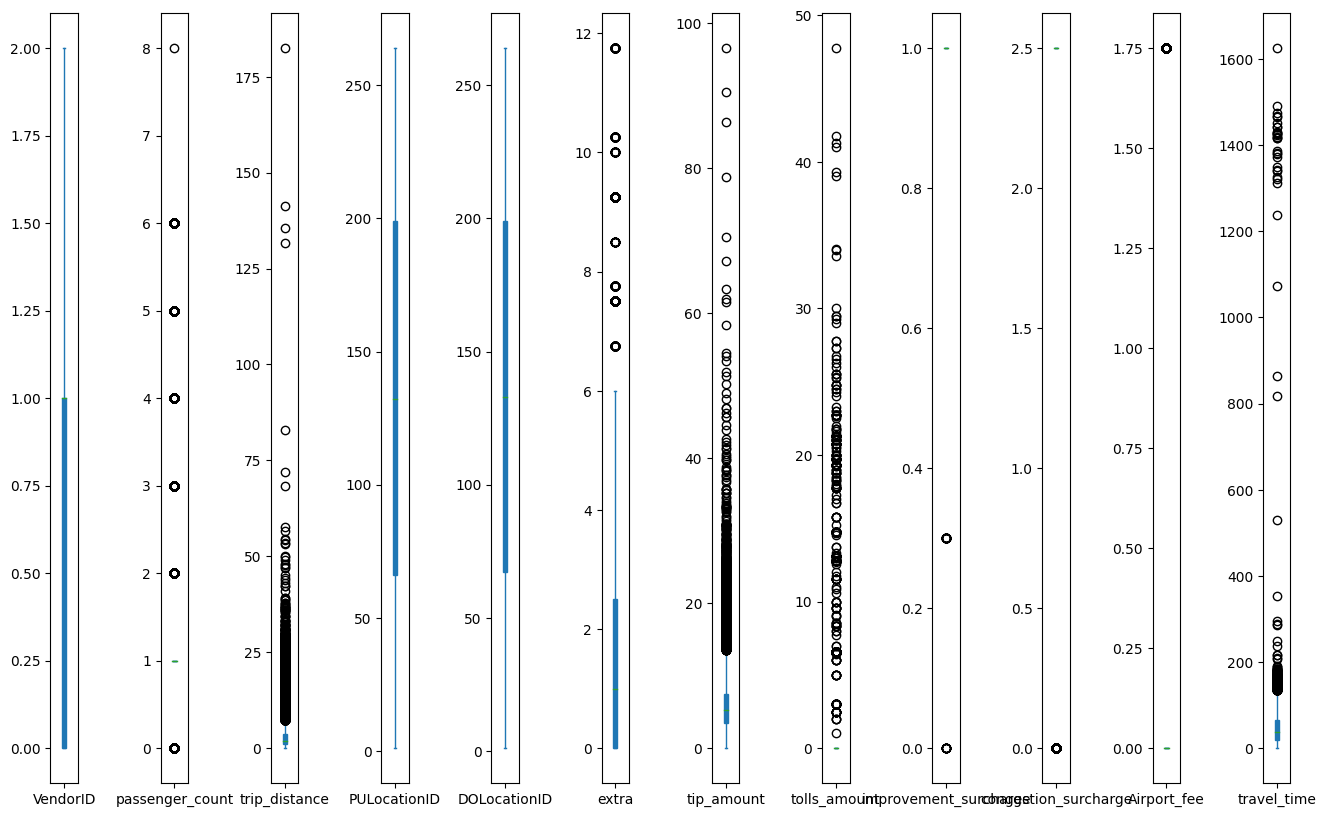

In [ ]:
test.plot(kind='box',sharey = False, subplots=True, figsize=(16,10),patch_artist=True,return_type='both')
plt.subplots_adjust(wspace = 3)
plt.show()

In [ ]:
test_si=si.fit_transform(test)
test=scaler.transform(test_si)

/opt/conda/lib/python3.10/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
#from sklearn.ensemble import BaggingRegressor
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.datasets import make_regression

# Create a base regressor (e.g., Decision Tree Regressor)
#base_regressor = DecisionTreeRegressor()

# Create a Bagging Regressor with the base regressor
#bagging_regressor = BaggingRegressor(base_regressor, n_estimators=10, random_state=42)

# Train the Bagging Regressor
#bagging_regressor.fit(X_train, y_train)

# Make predictions
#y_pred = bagging_regressor.predict(test)

# Evaluate the performance
#mse = mean_squared_error(y_test, y_pred)
#print(f'Mean Squared Error: {mse}')
#Score is 0.80914

In [ ]:
#from catboost import CatBoostRegressor
#model = CatBoostRegressor(iterations=1000, depth=6, learning_rate=0.1, loss_function='RMSE', random_seed=42)

#model.fit(X_train, y_train, verbose=100)

#y_pred = model.predict(test)
#y_pred2 = model.predict(X_val)

#mse = mean_squared_error(y_val, y_pred2)
#print(f'Mean Squared Error: {mse}')

#best_score = model.get_best_score()
#print(f'Best Score: {best_score}')
#r2 = r2_score(y_val, y_pred2)
#print(f'R^2 Score: {r2}')
#Score is 0.82444

In [ ]:
#from sklearn.ensemble import RandomForestRegressor

# Create RandomForestRegressor
#random_forest_regressor = RandomForestRegressor(n_estimators=10, random_state=42)

# Fit the model
#random_forest_regressor.fit(X_train, y_train)

# Make predictions
#y_pred = random_forest_regressor.predict(test)
#y_pred2 = random_forest_regressor.predict(X_val)
#r2 = r2_score(y_val, y_pred2)
#print(f'R^2 Score: {r2}')
#Score is 0.80526

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

# Base models
base_models = [('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
('gb', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))]

# Meta-model
meta_model = LinearRegression()

# Stacking Regressor
stacked_model = StackingRegressor(estimators=base_models, final_estimator=meta_model)

# Train the stacked model
stacked_model.fit(X_train, y_train)

# Make predictions on the validation set
y_val_pred = stacked_model.predict(X_val)

# Evaluate the performance
mse = mean_squared_error(y_val, y_val_pred)
print(f'Mean Squared Error on Validation Set: {mse}')

r2 = r2_score(y_val, y_val_pred)
print(f'R2 Score on Validation Set: {r2}')

# Now, you can use the stacked model for making predictions on the test set
y_pred = stacked_model.predict(test)


Mean Squared Error on Validation Set: 37.650912287910174
R2 Score on Validation Set: 0.9390020987828794


In [ ]:
submission = pd.DataFrame({'ID': np.arange(1,50001), 'total_amount': y_pred})
submission.to_csv("submission.csv", index=False)

In [ ]:
#import xgboost as xgb
#xgb = xgb.XGBRegressor(n_estimators=1000, max_depth=7, eta=0.1, subsample=0.7, colsample_bytree=0.8)
#xgb.fit(X_train, y_train)

# Predict on the test set
#y_pred = xgb.predict(test)
#y_pred2 = xgb.predict(X_val)


#mse = mean_squared_error(y_val, y_pred2)
##r2_score = r2_score(y_val, y_pred2)
#print(f'Mean Squared Error: {mse}')
#print(f'R2 score: {r2_score}')
#Score is 0.43441

In [ ]:
#from sklearn.tree import DecisionTreeRegressor

#clf = DecisionTreeRegressor()

# Train the classifier on the training data
#clf.fit(X_train, y_train)

# Make predictions on the test data
#y_pred = clf.predict(test)
#y_pred2 = clf.predict(X_val)

# Evaluate the accuracy of the classifier
#accuracy = accuracy_score(y_val, y_pred2)
#print(f"Accuracy: {accuracy:.2f}")
#Score is 0.78836

In [ ]:
#from sklearn.linear_model import Ridge
#from sklearn.metrics import mean_squared_error
#from sklearn.preprocessing import StandardScaler
#from sklearn.model_selection import GridSearchCV

# Assuming you have X_train, y_train, X_val, y_val, X_test

# Standardize the data (optional but recommended for ridge regression)
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_val_scaled = scaler.transform(X_val)
#X_test_scaled = scaler.transform(test)

# Create a Ridge regression model
#ridge_model = Ridge()

# Define a range of alpha values to try (alpha is the regularization strength)
#param_grid = {'alpha': [0.1, 1, 10, 100]}

# Use GridSearchCV to find the best alpha value using cross-validation on the training data
#grid_search = GridSearchCV(ridge_model, param_grid, cv=5)
#grid_search.fit(X_train_scaled, y_train)

# Get the best model with the optimal alpha value
#best_ridge_model = grid_search.best_estimator_

# Predict on the validation set
#y_val_pred = best_ridge_model.predict(X_val_scaled)

# Calculate mean squared error on the validation set
#mse_val = mean_squared_error(y_val, y_val_pred)
#print(f'Validation Mean Squared Error: {mse_val}')

# Predict on the test set
#y_pred = best_ridge_model.predict(X_test_scaled)

# You can use y_test_pred as your final predictions for the test set
#Score is 0.78002

In [ ]:
#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import r2_score
#from sklearn.model_selection import cross_val_score

#model = LinearRegression()
#model.fit(X_train,y_train)

#pred = model.predict(X_val)

#r2 = r2_score(y_val,pred)

#model.fit(X_train,y_train)

#y_pred = model.predict(test)
#print(r2)
#Score is 0.78002